# Semana 1 · Entendimiento del problema y formulación de hipótesis
**TP Churn de Clientes** — Inteligencia Artificial Aplicada a Negocios.

Esta semana **no modelamos ni validamos con estadística**: cargamos los datos, pasamos el checkpoint y *formulamos* 5 hipótesis de negocio, cada una con un gráfico simple y su lectura en lenguaje de negocio.

**Foco:** frenar el **churn temprano** y poder accionar. Por eso varias hipótesis miran al **cliente nuevo** (0–1 mes).

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd())=='notebooks': os.chdir('..')
sys.path.insert(0,'src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import data_prep as dp
sns.set_theme(style='whitegrid', palette='muted'); pd.set_option('display.max_columns',30)

Matplotlib is building the font cache; this may take a moment.


## 1. Checkpoint de la cátedra: cargar datos y `df.head()`
Cargamos el original (en `data/raw/`, intocable) y unificamos categorías duplicadas (`Phone`→`Mobile Phone`, `CC`→`Credit Card`, etc.).

In [2]:
df = dp.load_clean()
print('Filas x columnas:', df.shape)
print('Tasa de churn global:', f"{df['Churn'].mean():.1%}")
df.head()

Filas x columnas: (5630, 20)
Tasa de churn global: 16.8%


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
# Marcamos al cliente NUEVO (0-1 mes), foco del análisis
df['nuevo'] = np.where(df['Tenure'].fillna(99)<=1, 'Nuevo (0-1m)', 'Resto')

## 2. Las 5 hipótesis (formulación + gráfico + lectura de negocio)

### H1 · El riesgo de fuga se concentra en el primer mes
Los clientes nuevos, sin hábito ni costo de cambio, tendrían el mayor riesgo de irse.

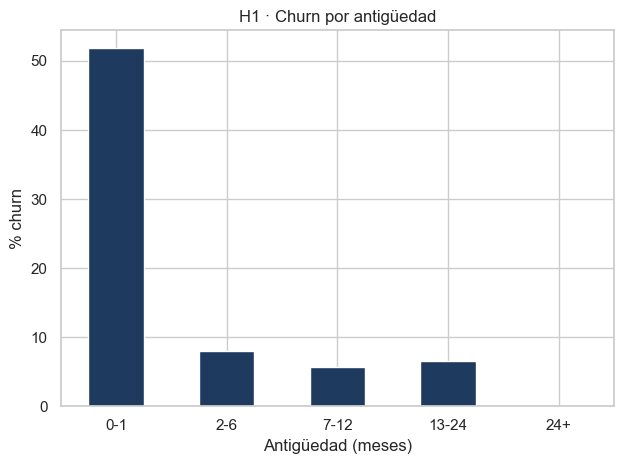

tramo
0-1      51.8
2-6       8.0
7-12      5.7
13-24     6.5
24+       0.0
Name: Churn, dtype: float64


In [4]:
g = df.dropna(subset=['Tenure']).copy()
g['tramo'] = pd.cut(g['Tenure'], [-1,1,6,12,24,100], labels=['0-1','2-6','7-12','13-24','24+'])
cr = g.groupby('tramo')['Churn'].mean().mul(100)
cr.plot(kind='bar', color='#1F3A5F', rot=0); plt.ylabel('% churn'); plt.xlabel('Antigüedad (meses)')
plt.title('H1 · Churn por antigüedad'); plt.tight_layout(); plt.show()
print(cr.round(1))

**Lectura de negocio:** el **51,8%** de los clientes de 0–1 mes se va; después del primer año, casi nadie. El primer mes es el campo de batalla. *Acción:* onboarding intensivo en los primeros 30 días.

### H2 · La queja de un cliente NUEVO es casi una baja segura ⭐
Un reclamo temprano debería disparar el churn mucho más que el de un cliente con antigüedad.

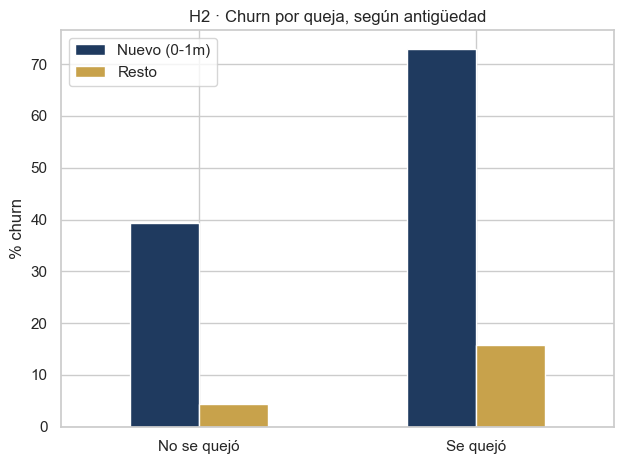

nuevo     Nuevo (0-1m)  Resto
Complain                     
0                 39.4    4.4
1                 72.9   15.8


In [5]:
piv = df.pivot_table('Churn','Complain','nuevo',aggfunc='mean').mul(100)
piv.plot(kind='bar', color=['#1F3A5F','#C8A24B']); plt.xticks([0,1],['No se quejó','Se quejó'],rotation=0)
plt.xlabel(''); plt.ylabel('% churn'); plt.title('H2 · Churn por queja, según antigüedad'); plt.legend(title=''); plt.tight_layout(); plt.show()
print(piv.round(1))

**Lectura de negocio:** un cliente nuevo que se queja se va el **~73%** de las veces (vs. 39% del nuevo sin queja). *Acción:* respuesta y seguimiento prioritario a quejas de clientes con < 30 días.

### H3 · La satisfacción declarada NO protege del churn ⭐ (contraintuitiva)
Hipótesis 'obvia' a poner a prueba: ¿menor satisfacción = más churn?

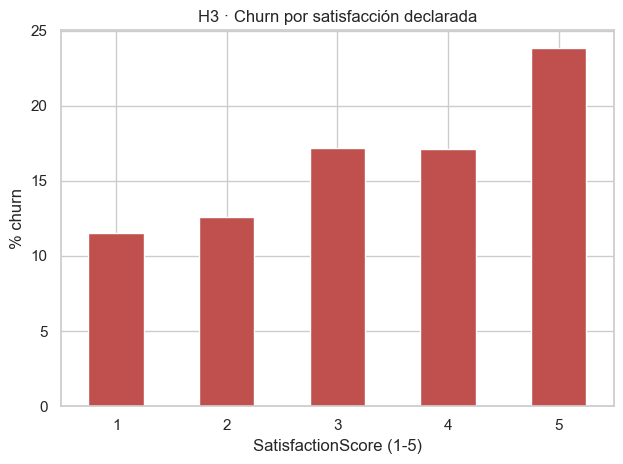

SatisfactionScore
1    11.5
2    12.6
3    17.2
4    17.1
5    23.8
Name: Churn, dtype: float64


In [6]:
cr = df.groupby('SatisfactionScore')['Churn'].mean().mul(100)
cr.plot(kind='bar', color='#C0504D', rot=0); plt.xlabel('SatisfactionScore (1-5)'); plt.ylabel('% churn')
plt.title('H3 · Churn por satisfacción declarada'); plt.tight_layout(); plt.show()
print(cr.round(1))

**Lectura de negocio:** da **al revés**: los de score 5 se van *más* (23,8%) que los de score 1 (11,5%). El score no es un buen termómetro de retención. *Acción:* basar la alerta de riesgo en comportamiento (antigüedad, quejas), no en encuestas. **Esto es validar en vez de asumir.**

### H4 · En tier 2 y 3 se churnea más — y ahí las quejas pegan más fuerte ⭐
Peor experiencia/logística fuera de las grandes ciudades amplificaría el efecto de una mala atención.

Churn por tier:
CityTier
1    14.5
2    19.8
3    21.4
Name: Churn, dtype: float64


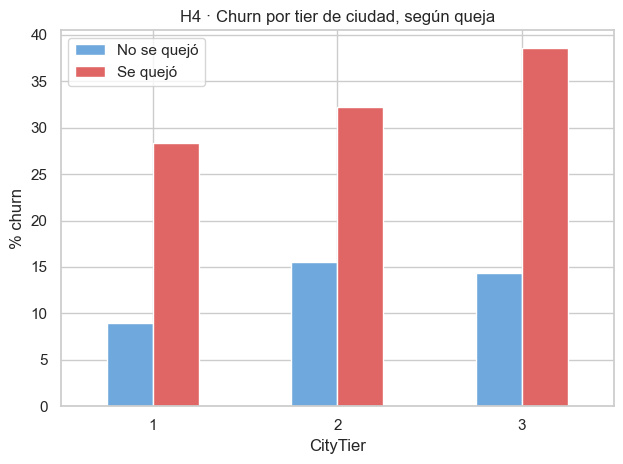

          No se quejó  Se quejó
CityTier                       
1                 9.0      28.4
2                15.6      32.3
3                14.4      38.6


In [7]:
print('Churn por tier:'); print(df.groupby('CityTier')['Churn'].mean().mul(100).round(1))
piv = df.pivot_table('Churn','CityTier','Complain',aggfunc='mean').mul(100)
piv.columns = ['No se quejó','Se quejó']
piv.plot(kind='bar', color=['#6fa8dc','#e06666'], rot=0); plt.xlabel('CityTier'); plt.ylabel('% churn')
plt.title('H4 · Churn por tier de ciudad, según queja'); plt.legend(title=''); plt.tight_layout(); plt.show()
print(piv.round(1))

**Lectura de negocio:** Tier 3 (21,4%) y Tier 2 (19,8%) superan a Tier 1 (14,5%); y una queja en Tier 3 lleva el churn a **38,6%**. *Acción:* reforzar servicio y tiempos de entrega en tier 2/3, y priorizar sus quejas.

### H5 · Más dispositivos registrados = más riesgo ⭐ (contraintuitiva)
Contra la intuición de 'más enganchado': muchos dispositivos podrían indicar cuentas compartidas o comparación de precios.

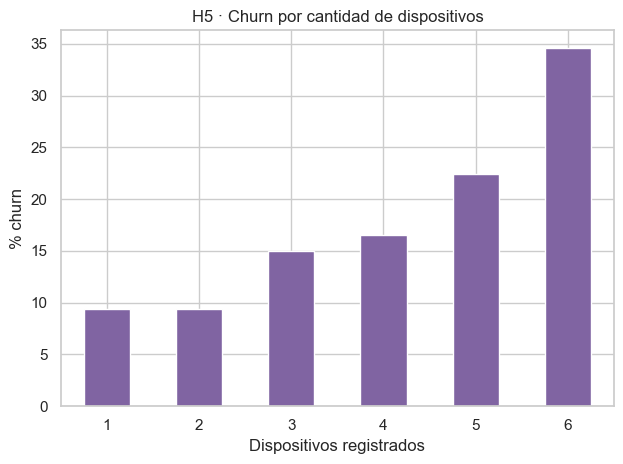

NumberOfDeviceRegistered
1     9.4
2     9.4
3    14.9
4    16.5
5    22.5
6    34.6
Name: Churn, dtype: float64


In [8]:
cr = df.groupby('NumberOfDeviceRegistered')['Churn'].mean().mul(100)
cr.plot(kind='bar', color='#8064A2', rot=0); plt.xlabel('Dispositivos registrados'); plt.ylabel('% churn')
plt.title('H5 · Churn por cantidad de dispositivos'); plt.tight_layout(); plt.show()
print(cr.round(1))

**Lectura de negocio:** de 1–2 dispositivos (~9%) a 6 dispositivos (**34,6%**), el riesgo se multiplica. *Acción:* investigar señales de multicuenta y 'shopping around'; no asumir que más actividad = más lealtad.

## 3. Cierre de Semana 1
- Checkpoint OK: datos cargados, `df.head()` corre.
- 5 hipótesis formuladas con lógica de negocio y una primera lectura visual.
- Todas giran alrededor de **detectar y frenar el churn temprano**.

**Próxima semana (S2):** validar cada hipótesis con test estadístico, controlar confusores (sobre todo la antigüedad) y preparar el split.